Basal


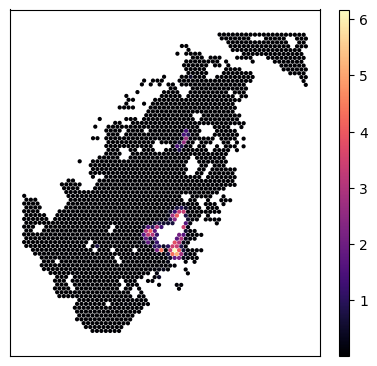

In [1]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
import math
from IPython.core.pylabtools import figsize
import pandas as pd


cell_names = [cell[23:] for cell in list(pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/WSA_LngSP8759311/cell_ratio.csv").columns)[1:]]

case = "A37"
slide = "WSA_LngSP10193347"
selected_cell_names = ['Basal', 'Ciliated', 'Fibro_adventitial']

save_path = "/data1/r20user3/shared_project/Hist2Cell/code/analysis/inference/humanlung/humanlung_epoch100_lr1e-4_2hop_ensemble_onlycell_"+case+"_best_cell_all_abundance_average.pkl"
pred_and_label = joblib.load(save_path)

pred_and_label[slide]['cell_abundance_predictions'] = np.clip(pred_and_label[slide]['cell_abundance_predictions'], a_min=0, a_max=None)
pred_ratio = pred_and_label[slide]['cell_abundance_predictions'] / pred_and_label[slide]['cell_abundance_predictions'].sum(axis=1, keepdims=True)
real_ratio = pred_and_label[slide]['cell_abundance_labels'] / pred_and_label[slide]['cell_abundance_labels'].sum(axis=1, keepdims=True)

coordinates = pred_and_label[slide]['coords']
X = coordinates[:, 0]
Y = coordinates[:, 1]

counts = pred_and_label[slide]['cell_abundance_labels']
for i in range(39):
    if cell_names[i] in selected_cell_names:
        print(cell_names[i])
        
        A = counts[:, i]
        # Calculate the minimum distance between points
        min_distance = np.min([math.sqrt((coordinates[i][0] - coordinates[j][0])**2 + (coordinates[i][1] - coordinates[j][1])**2) for i in range(len(coordinates)) for j in range(i+1, len(coordinates))])
        # Set the node size as a fraction of the minimum distance (e.g., 25%)
        node_size = min_distance * 0.018
        # set figure size
        figsize(5, 4.5)
        # Create a scatter plot with a color map
        scatter_plot = plt.scatter(X, Y, c=A, cmap='magma', s=node_size)
        # Add a color bar with the spot values
        cbar = plt.colorbar(scatter_plot, shrink=1.0, aspect=35)
        plt.gca().invert_yaxis()
        # Adjust the plot size to match the range of X and Y coordinates
        plt.xlim(min(coordinates[:, 0]), max(coordinates[:, 0]))
        plt.ylim(max(coordinates[:, 1]), min(coordinates[:, 1]))
        # Show the plot
        plt.axis('equal')
        plt.xticks([])
        plt.yticks([])
        # plt.savefig(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/spatial_visualization/humanlung", case, slide, "cell abundance", cell_names[i]+"_Cell2location.png"))
        plt.show()
        plt.close()
        break

In [2]:
from tkinter import font


max_indices = counts.argmax(axis=1)
A = max_indices

# 创建一个字典将不连续的类别映射到连续的类别
unique_classes = sorted(set(A))
class_mapping = {c: i for i, c in enumerate(unique_classes)}
reverse_class_mapping = {i: c for i, c in enumerate(unique_classes)}

# 使用映射将A中的类别转换为连续的类别
A_continuous = [class_mapping[a] for a in A]

# Calculate the minimum distance between points
min_distance = np.min([math.sqrt((coordinates[i][0] - coordinates[j][0])**2 + (coordinates[i][1] - coordinates[j][1])**2) for i in range(len(coordinates)) for j in range(i+1, len(coordinates))])
# Set the node size as a fraction of the minimum distance (e.g., 25%)
node_size = min_distance * 0.018
# set figure size
figsize(5, 4.5)

# 获取类别数量
num_classes = len(set(A_continuous))

# 生成颜色列表
colors = sns.color_palette("husl", num_classes)

# 为每个标签创建一个散点图
for label in set(A_continuous):
    x = [X[i] for i in range(len(A_continuous)) if A_continuous[i] == label]
    y = [Y[i] for i in range(len(A_continuous)) if A_continuous[i] == label]
    plt.scatter(x, y, color=colors[label], label=cell_names[reverse_class_mapping[label]], s=node_size)

# 显示图例
plt.legend(fontsize=4, loc='lower right')

plt.gca().invert_yaxis()
# Adjust the plot size to match the range of X and Y coordinates
plt.xlim(min(coordinates[:, 0]), max(coordinates[:, 0]))
plt.ylim(max(coordinates[:, 1]), min(coordinates[:, 1]))
# Show the plot
plt.axis('equal')
plt.xticks([])
plt.yticks([])
# plt.savefig(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/spatial_visualization/humanlung", case, slide, "cell abundance", cell_names[i]+"_Cell2location.png"))
plt.show()
plt.close()

NameError: name 'sns' is not defined

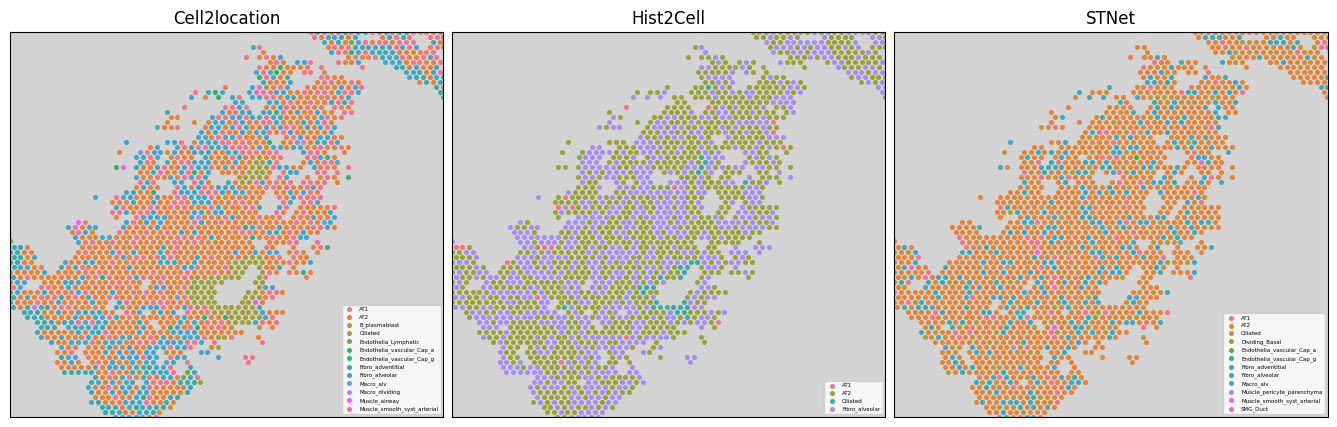

In [34]:
import math
from IPython.core.pylabtools import figsize


save_path = "/data1/r20user3/shared_project/Hist2Cell/code/analysis/inference/humanlung/humanlung_epoch100_lr1e-4_2hop_ensemble_onlycell_"+case+"_best_cell_all_abundance_average.pkl"
pred_and_label = joblib.load(save_path)
pred_and_label[slide]['cell_abundance_predictions'] = np.clip(pred_and_label[slide]['cell_abundance_predictions'], a_min=0, a_max=None)
pred_and_label[slide]['cell_abundance_labels'] = np.clip(pred_and_label[slide]['cell_abundance_labels'], a_min=0, a_max=None)

coordinates = pred_and_label[slide]['coords']
X = coordinates[:, 0]
Y = coordinates[:, 1]

cell2location_counts = pred_and_label[slide]['cell_abundance_labels']
hist2cell_counts = pred_and_label[slide]['cell_abundance_predictions']

save_path = "/data1/r20user3/shared_project/Hist2Cell/code/analysis/inference/humanlung/humanlung_epoch100_lr1e-4_densenet_onlycell_"+case+"_best_cell_all_abundance_average.pkl"
pred_and_label = joblib.load(save_path)
pred_and_label[slide]['cell_abundance_predictions'] = np.clip(pred_and_label[slide]['cell_abundance_predictions'], a_min=0, a_max=None)

stnet_counts = pred_and_label[slide]['cell_abundance_predictions']

# Calculate the minimum distance between points
min_distance = np.min([math.sqrt((coordinates[i][0] - coordinates[j][0])**2 + (coordinates[i][1] - coordinates[j][1])**2) for i in range(len(coordinates)) for j in range(i+1, len(coordinates))])
# Set the node size as a fraction of the minimum distance (e.g., 25%)
node_size = min_distance * 0.030

figsize(17, 5)

# Create subplots for cell2location_count2, hist2cell_counts, and stnet_counts
fig, axs = plt.subplots(1, 3)
# Reduce the space between subplots
plt.subplots_adjust(wspace=0.02)

# Set the background color of each scatter plot to light gray
axs[0].set_facecolor('lightgray')
axs[1].set_facecolor('lightgray')
axs[2].set_facecolor('lightgray')

# cell2location_count2 plot
max_indices = cell2location_counts.argmax(axis=1)
A = max_indices
# 创建一个字典将不连续的类别映射到连续的类别
unique_classes = sorted(set(A))
class_mapping = {c: i for i, c in enumerate(unique_classes)}
reverse_class_mapping = {i: c for i, c in enumerate(unique_classes)}
# 使用映射将A中的类别转换为连续的类别
A_continuous = [class_mapping[a] for a in A]
# 获取类别数量
num_classes = len(set(A_continuous))
# 生成颜色列表
colors = sns.color_palette("husl", num_classes)
# 为每个标签创建一个散点图
for label in set(A_continuous):
    x = [X[i] for i in range(len(A_continuous)) if A_continuous[i] == label]
    y = [Y[i] for i in range(len(A_continuous)) if A_continuous[i] == label]
    scatter_plot = axs[0].scatter(x, y, color=colors[label], label=cell_names[reverse_class_mapping[label]], s=node_size)
# 显示图例
axs[0].legend(fontsize=4, loc='lower right')
axs[0].invert_yaxis()

# Adjust the plot size to match the range of X and Y coordinates
axs[0].set_xlim(min(coordinates[:, 0]), max(coordinates[:, 0]))
axs[0].set_ylim(max(coordinates[:, 1]), min(coordinates[:, 1]))
axs[0].set_xticks([])
axs[0].set_yticks([])
axs[0].set_title("Cell2location")

# hist2cell_counts plot
max_indices = hist2cell_counts.argmax(axis=1)
A = max_indices
# 创建一个字典将不连续的类别映射到连续的类别
unique_classes = sorted(set(A))
class_mapping = {c: i for i, c in enumerate(unique_classes)}
reverse_class_mapping = {i: c for i, c in enumerate(unique_classes)}
# 使用映射将A中的类别转换为连续的类别
A_continuous = [class_mapping[a] for a in A]
# 获取类别数量
num_classes = len(set(A_continuous))
# 生成颜色列表
colors = sns.color_palette("husl", num_classes)
# 为每个标签创建一个散点图
for label in set(A_continuous):
    x = [X[i] for i in range(len(A_continuous)) if A_continuous[i] == label]
    y = [Y[i] for i in range(len(A_continuous)) if A_continuous[i] == label]
    scatter_plot = axs[1].scatter(x, y, color=colors[label], label=cell_names[reverse_class_mapping[label]], s=node_size)
# 显示图例
axs[1].legend(fontsize=4, loc='lower right')
axs[1].invert_yaxis()
# Adjust the plot size to match the range of X and Y coordinates
axs[1].set_xlim(min(coordinates[:, 0]), max(coordinates[:, 0]))
axs[1].set_ylim(max(coordinates[:, 1]), min(coordinates[:, 1]))
axs[1].set_xticks([])
axs[1].set_yticks([])
axs[1].set_title("Hist2Cell")

# stnet_counts plot
max_indices = stnet_counts.argmax(axis=1)
A = max_indices
# 创建一个字典将不连续的类别映射到连续的类别
unique_classes = sorted(set(A))
class_mapping = {c: i for i, c in enumerate(unique_classes)}
reverse_class_mapping = {i: c for i, c in enumerate(unique_classes)}
# 使用映射将A中的类别转换为连续的类别
A_continuous = [class_mapping[a] for a in A]
# 获取类别数量
num_classes = len(set(A_continuous))
# 生成颜色列表
colors = sns.color_palette("husl", num_classes)
# 为每个标签创建一个散点图
for label in set(A_continuous):
    x = [X[i] for i in range(len(A_continuous)) if A_continuous[i] == label]
    y = [Y[i] for i in range(len(A_continuous)) if A_continuous[i] == label]
    scatter_plot = axs[2].scatter(x, y, color=colors[label], label=cell_names[reverse_class_mapping[label]], s=node_size)
# 显示图例
axs[2].legend(fontsize=4, loc='lower right')
axs[2].invert_yaxis()
# Adjust the plot size to match the range of X and Y coordinates
axs[2].set_xlim(min(coordinates[:, 0]), max(coordinates[:, 0]))
axs[2].set_ylim(max(coordinates[:, 1]), min(coordinates[:, 1]))
axs[2].set_xticks([])
axs[2].set_yticks([])
axs[2].set_title("STNet")
# plt.savefig(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/spatial_visualization/humanlung", case, slide, "cell abundance", cell_names[i]+"_Cell2location.png"))
plt.show()
plt.close()

In [37]:
from glob import glob
import os
import seaborn as sns

tif_list = glob('/data1/r20user3/shared_project/Hist2Cell/code/training/train_test_splits/humanlung_cell2location/test*')
tif_list.sort()
test_slides = list()
for tif in tif_list:
    tif_path = tif.split('_')[-1].split('.')[0]
    test_slides.append(tif_path)
    
cell_names = [cell[23:] for cell in list(pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/WSA_LngSP8759311/cell_ratio.csv").columns)[1:]]

os.mkdir("/data1/r20user3/shared_project/Hist2Cell/code/analysis/spatial_visualization/humanlung/largest_proportion")
for case in test_slides:
    save_path = "/data1/r20user3/shared_project/Hist2Cell/code/analysis/inference/humanlung/humanlung_epoch100_lr1e-4_densenet_onlycell_"+case+"_best_cell_all_abundance_average.pkl"
    slide_list = joblib.load(save_path)
    
    case_pred = list()
    case_label = list()
    
    for slide in slide_list:
        
        save_path = "/data1/r20user3/shared_project/Hist2Cell/code/analysis/inference/humanlung/humanlung_epoch100_lr1e-4_2hop_ensemble_onlycell_"+case+"_best_cell_all_abundance_average.pkl"
        pred_and_label = joblib.load(save_path)
        pred_and_label[slide]['cell_abundance_predictions'] = np.clip(pred_and_label[slide]['cell_abundance_predictions'], a_min=0, a_max=None)
        pred_and_label[slide]['cell_abundance_labels'] = np.clip(pred_and_label[slide]['cell_abundance_labels'], a_min=0, a_max=None)

        coordinates = pred_and_label[slide]['coords']
        X = coordinates[:, 0]
        Y = coordinates[:, 1]

        cell2location_counts = pred_and_label[slide]['cell_abundance_labels']
        hist2cell_counts = pred_and_label[slide]['cell_abundance_predictions']

        save_path = "/data1/r20user3/shared_project/Hist2Cell/code/analysis/inference/humanlung/humanlung_epoch100_lr1e-4_densenet_onlycell_"+case+"_best_cell_all_abundance_average.pkl"
        pred_and_label = joblib.load(save_path)
        pred_and_label[slide]['cell_abundance_predictions'] = np.clip(pred_and_label[slide]['cell_abundance_predictions'], a_min=0, a_max=None)

        stnet_counts = pred_and_label[slide]['cell_abundance_predictions']

        # Calculate the minimum distance between points
        min_distance = np.min([math.sqrt((coordinates[i][0] - coordinates[j][0])**2 + (coordinates[i][1] - coordinates[j][1])**2) for i in range(len(coordinates)) for j in range(i+1, len(coordinates))])
        # Set the node size as a fraction of the minimum distance (e.g., 25%)
        node_size = min_distance * 0.030

        figsize(17, 5)

        # Create subplots for cell2location_count2, hist2cell_counts, and stnet_counts
        fig, axs = plt.subplots(1, 3)
        # Reduce the space between subplots
        plt.subplots_adjust(wspace=0.02)

        # Set the background color of each scatter plot to light gray
        axs[0].set_facecolor('lightgray')
        axs[1].set_facecolor('lightgray')
        axs[2].set_facecolor('lightgray')

        # cell2location_count2 plot
        max_indices = cell2location_counts.argmax(axis=1)
        A = max_indices
        # 创建一个字典将不连续的类别映射到连续的类别
        unique_classes = sorted(set(A))
        class_mapping = {c: i for i, c in enumerate(unique_classes)}
        reverse_class_mapping = {i: c for i, c in enumerate(unique_classes)}
        # 使用映射将A中的类别转换为连续的类别
        A_continuous = [class_mapping[a] for a in A]
        # 获取类别数量
        num_classes = len(set(A_continuous))
        # 生成颜色列表
        colors = sns.color_palette("husl", num_classes)
        # 为每个标签创建一个散点图
        for label in set(A_continuous):
            x = [X[i] for i in range(len(A_continuous)) if A_continuous[i] == label]
            y = [Y[i] for i in range(len(A_continuous)) if A_continuous[i] == label]
            scatter_plot = axs[0].scatter(x, y, color=colors[label], label=cell_names[reverse_class_mapping[label]], s=node_size)
        # 显示图例
        axs[0].legend(fontsize=4, loc='lower right')
        axs[0].invert_yaxis()

        # Adjust the plot size to match the range of X and Y coordinates
        axs[0].set_xlim(min(coordinates[:, 0]), max(coordinates[:, 0]))
        axs[0].set_ylim(max(coordinates[:, 1]), min(coordinates[:, 1]))
        axs[0].set_xticks([])
        axs[0].set_yticks([])
        axs[0].set_title("Cell2location")

        # hist2cell_counts plot
        max_indices = hist2cell_counts.argmax(axis=1)
        A = max_indices
        # 创建一个字典将不连续的类别映射到连续的类别
        unique_classes = sorted(set(A))
        class_mapping = {c: i for i, c in enumerate(unique_classes)}
        reverse_class_mapping = {i: c for i, c in enumerate(unique_classes)}
        # 使用映射将A中的类别转换为连续的类别
        A_continuous = [class_mapping[a] for a in A]
        # 获取类别数量
        num_classes = len(set(A_continuous))
        # 生成颜色列表
        colors = sns.color_palette("husl", num_classes)
        # 为每个标签创建一个散点图
        for label in set(A_continuous):
            x = [X[i] for i in range(len(A_continuous)) if A_continuous[i] == label]
            y = [Y[i] for i in range(len(A_continuous)) if A_continuous[i] == label]
            scatter_plot = axs[1].scatter(x, y, color=colors[label], label=cell_names[reverse_class_mapping[label]], s=node_size)
        # 显示图例
        axs[1].legend(fontsize=4, loc='lower right')
        axs[1].invert_yaxis()
        # Adjust the plot size to match the range of X and Y coordinates
        axs[1].set_xlim(min(coordinates[:, 0]), max(coordinates[:, 0]))
        axs[1].set_ylim(max(coordinates[:, 1]), min(coordinates[:, 1]))
        axs[1].set_xticks([])
        axs[1].set_yticks([])
        axs[1].set_title("Hist2Cell")

        # stnet_counts plot
        max_indices = stnet_counts.argmax(axis=1)
        A = max_indices
        # 创建一个字典将不连续的类别映射到连续的类别
        unique_classes = sorted(set(A))
        class_mapping = {c: i for i, c in enumerate(unique_classes)}
        reverse_class_mapping = {i: c for i, c in enumerate(unique_classes)}
        # 使用映射将A中的类别转换为连续的类别
        A_continuous = [class_mapping[a] for a in A]
        # 获取类别数量
        num_classes = len(set(A_continuous))
        # 生成颜色列表
        colors = sns.color_palette("husl", num_classes)
        # 为每个标签创建一个散点图
        for label in set(A_continuous):
            x = [X[i] for i in range(len(A_continuous)) if A_continuous[i] == label]
            y = [Y[i] for i in range(len(A_continuous)) if A_continuous[i] == label]
            scatter_plot = axs[2].scatter(x, y, color=colors[label], label=cell_names[reverse_class_mapping[label]], s=node_size)
        # 显示图例
        axs[2].legend(fontsize=4, loc='lower right')
        axs[2].invert_yaxis()
        # Adjust the plot size to match the range of X and Y coordinates
        axs[2].set_xlim(min(coordinates[:, 0]), max(coordinates[:, 0]))
        axs[2].set_ylim(max(coordinates[:, 1]), min(coordinates[:, 1]))
        axs[2].set_xticks([])
        axs[2].set_yticks([])
        axs[2].set_title("STNet")
        plt.savefig(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/spatial_visualization/humanlung/largest_proportion", case+"_"+slide+"_"+"largest_proportion.png"))
        # plt.show()
        plt.close()